#Paper utilizado:

[1] M. Bahaghighat, M. Ghasemi y F. Ozen,
“A high-accuracy phishing website detection method based on machine learning,”
Journal of Information Security and Applications,
vol. 77,
art. 103553,
2023.
doi: 10.1016/j.jisa.2023.103553.
Available: https://www.sciencedirect.com/science/article/pii/S2214212623001370

#Limpieza de datos

En este colab se realizará la limpieza del set de datos para el entrenamiento de un modelo de inteligencia artificial. El dataset que se está usando es el de Abdelhamid, N. (2014). Website Phishing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5B301.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_limpio = pd.read_excel("/content/WebPhish.xlsx")

In [ ]:
df_limpio.shape

(1353, 10)

#Separación de dataset en train, test y validate

En el dataset tenemos:
- 702 sitios phishing
- 548 sitios legítimos
- 103 sitios sospechosos

Esto nos da suficients datos de sitios legítimos y de sitios de phishing, pero puede estar algo justo para la identificación de sitios sospechosos.

Aún así decidí dejar un split de 80 20 en train y test. Esto nos deja al menos 20 ejemplos de sitios sospechosos y 80 para el entrenamiento. Sin embargo como también el entrenamiento se tiene que dividir, puede ser algo difícil entrenar al modelo para distinguir los sitios sospechosos.

##En las posibles mejoras futuras se podría tratar de aumentar artificialmente la proporciónn de sitios sospechosos por medio de una herramienta como SMOTE (Synthetic Minority Oversampling Technique).



In [ ]:
from sklearn.model_selection import train_test_split
#Ahora sí separamos los datos
X = df_limpio.drop("Result", axis=1)
y = df_limpio["Result"]

X_train80, X_test, y_train80, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,

    #permite mantener proporciones de y en la separación
    stratify=y
)

In [ ]:
X_train, X_validate, y_train, y_validate = train_test_split(
    X_train80,
    y_train80,
    test_size=0.2,
    random_state=42,

    stratify=y_train80
)

In [ ]:
from imblearn.combine import SMOTEENN
from collections import Counter

print("Antes de SMOTEENN:")
print(Counter(y_train))

smoteenn = SMOTEENN(random_state=42)

X_train_res, y_train_res = smoteenn.fit_resample(X_train, y_train)

print("\nDespués de SMOTEENN:")
print(Counter(y_train_res))

print("Shape original:", X_train.shape)
print("Shape balanceado:", X_train_res.shape)

X_train = X_train_res
y_train = y_train_res

Antes de SMOTEENN:
Counter({0: 449, 2: 350, 1: 66})

Después de SMOTEENN:
Counter({1: 413, 0: 350, 2: 342})
Shape original: (865, 9)
Shape balanceado: (1105, 9)


#Tratamiento de datos

Código para agregar algunas columnas que pueden servir para el análisis y cambio en los formatos de datos.

Para este problema como todas las columnas son

##Escalamiento (one hot encoding)

In [ ]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_validate_encoded = pd.get_dummies(X_validate)


print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_validate_encoded.shape)

(1105, 9)
(271, 9)
(217, 9)


#Aquí me di cuenta que mi encoding no hizo nada porque dummies no cambia variables numericas, sino categoricas, en el siguiente código fuerzo a que se traten como categoricas.

In [ ]:
X_train_encoded = pd.get_dummies(
    X_train.astype("category")
)

X_test_encoded = pd.get_dummies(
    X_test.astype("category")
)

X_validate_encoded = pd.get_dummies(
    X_validate.astype("category")
)

In [ ]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_validate_encoded.shape)

(1105, 26)
(271, 25)
(217, 25)


Ambas columnas deberían ser iguales, por ello hay que alinearlas, ya que si no no se puede predecir. En este caso sí son iguales.

Lo que hacemos es si en test hay (azul/amarillo) y en train hay (azul/rojo), vamos a tener en ambos (azul/amarillo/rojo)

In [ ]:
# Alinear columnas
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

X_train_encoded, X_validate_encoded = X_train_encoded.align(
    X_validate_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_validate_encoded.shape)

(1105, 26)
(271, 26)
(217, 26)


In [ ]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105 entries, 0 to 1104
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   SFH_-1               1105 non-null   bool 
 1   SFH_0                1105 non-null   bool 
 2   SFH_1                1105 non-null   bool 
 3   popUpWindow_-1       1105 non-null   bool 
 4   popUpWindow_0        1105 non-null   bool 
 5   popUpWindow_1        1105 non-null   bool 
 6   SSLfinal_State_-1    1105 non-null   bool 
 7   SSLfinal_State_0     1105 non-null   bool 
 8   SSLfinal_State_1     1105 non-null   bool 
 9   Request_URL_-1       1105 non-null   bool 
 10  Request_URL_0        1105 non-null   bool 
 11  Request_URL_1        1105 non-null   bool 
 12  URL_of_Anchor_-1     1105 non-null   bool 
 13  URL_of_Anchor_0      1105 non-null   bool 
 14  URL_of_Anchor_1      1105 non-null   bool 
 15  web_traffic_-1       1105 non-null   bool 
 16  web_traffic_0        110

In [ ]:
X_train_encoded.describe(include='all').T

,count,unique,top,freq
SFH_-1,1105,2,False,677
SFH_0,1105,2,False,922
SFH_1,1105,2,False,611
popUpWindow_-1,1105,2,False,659
popUpWindow_0,1105,2,True,556
popUpWindow_1,1105,2,False,1002
SSLfinal_State_-1,1105,2,False,896
SSLfinal_State_0,1105,2,False,808
SSLfinal_State_1,1105,2,True,599
Request_URL_-1,1105,2,True,611


#Función para evaluar los modelos:

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def get_metrics(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return accuracy, precision, recall, f1

#Entrenamiento de datos

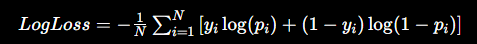

#Revisión de hiperparámetros default

In [ ]:
from sklearn.linear_model import SGDClassifier

print(SGDClassifier())

SGDClassifier()


In [ ]:
SGDClassifier().get_params()

{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.0,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'hinge',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': None,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

##Mejora agregamos

penalty='l2', maneja los pesos sin eliminar variables.

alpha=0.0001, La regularización añade una penalización a los coeficientes grandes para evitar que el modelo se ajuste demasiado a los datos de entrenamiento. Dice qué tan fuerte es el penalty

eta0=0.01, learning rate



In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier

log_model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0005,
    eta0=0.0005, #learning rate,
    random_state=42
)

epochs = 30

train_acc = []
test_acc = []
validate_acc = []

train_f1 = []
test_f1 = []
validate_f1 = []

for epoch in range(epochs):

    log_model.partial_fit(
        X_train_encoded,
        y_train,
        classes=y_train.unique()
    )

    # Predicciones
    y_train_pred = log_model.predict(X_train_encoded)
    y_test_pred = log_model.predict(X_test_encoded)
    y_validate_pred = log_model.predict(X_validate_encoded)

    # Métricas
    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)
    validate_metrics = get_metrics(y_validate, y_validate_pred)

    # Accuracy
    train_acc.append(train_metrics[0])
    test_acc.append(test_metrics[0])
    validate_acc.append(validate_metrics[0])

    # F1
    train_f1.append(train_metrics[3])
    test_f1.append(test_metrics[3])
    validate_f1.append(validate_metrics[3])

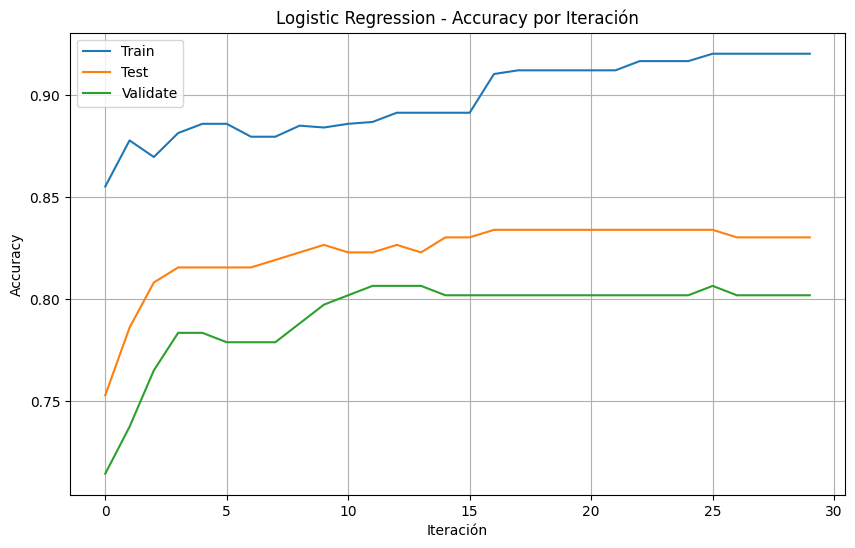

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.plot(train_acc, label='Train')
plt.plot(test_acc, label='Test')
plt.plot(validate_acc, label='Validate')

plt.xlabel('Iteración')
plt.ylabel('Accuracy')
plt.title('Logistic Regression - Accuracy por Iteración')

plt.legend()
plt.grid()

plt.show()

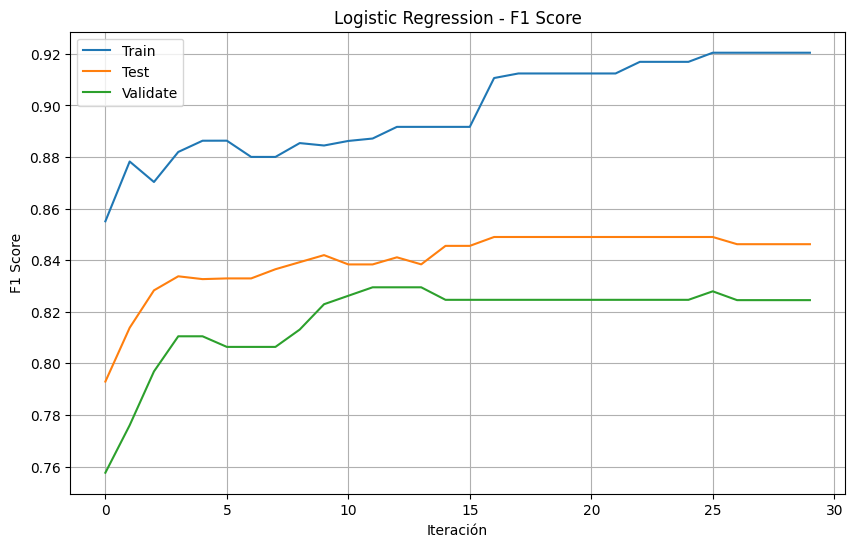

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(train_f1, label='Train')
plt.plot(test_f1, label='Test')
plt.plot(validate_f1, label='Validate')

plt.xlabel('Iteración')
plt.ylabel('F1 Score')
plt.title('Logistic Regression - F1 Score')

plt.legend()
plt.grid()

plt.show()

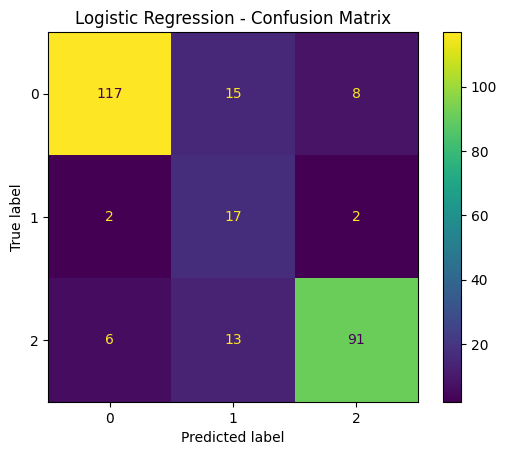

In [ ]:
y_pred_log = log_model.predict(X_test_encoded)

cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log
)

disp.plot()

plt.title('Logistic Regression - Confusion Matrix')

plt.show()

Aqui podemos ver que el modelo tiene mucho problema con la clasificación de sitios sospechosos a pesar de que es bueno para detectar phishing y sitios seguros.

#Random forest

### Hiperparámetros:
n_estimators (estimator): número de árboles

max_depth: a mayor profundidad permite encontrar aprender patrones más complejos pero puede causar overfitting

min_samples_leaf: Mínimo de muestras por hoja. Al aumentar disminuye el overfitting

In [ ]:
from sklearn.ensemble import RandomForestClassifier

train_acc_rf = []
test_acc_rf = []
validate_acc_rf = []

train_f1_rf = []
test_f1_rf = []
validate_f1_rf = []

estimators_range = range(25, 151)

for n in estimators_range:

    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        max_depth=10,
        min_samples_leaf=2

    )

    rf_model.fit(X_train_encoded, y_train)

    y_train_pred = rf_model.predict(X_train_encoded)
    y_test_pred = rf_model.predict(X_test_encoded)
    y_validate_pred = rf_model.predict(X_validate_encoded)

    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)
    validate_metrics = get_metrics(y_validate, y_validate_pred)

    # Accuracy
    train_acc_rf.append(train_metrics[0])
    test_acc_rf.append(test_metrics[0])
    validate_acc_rf.append(validate_metrics[0])

    # F1
    train_f1_rf.append(train_metrics[3])
    test_f1_rf.append(test_metrics[3])
    validate_f1_rf.append(validate_metrics[3])

###Nota:
Las siguientes gráficas no son de iteraciones sino de muchos modelos de random forest con diferentes números de árboles

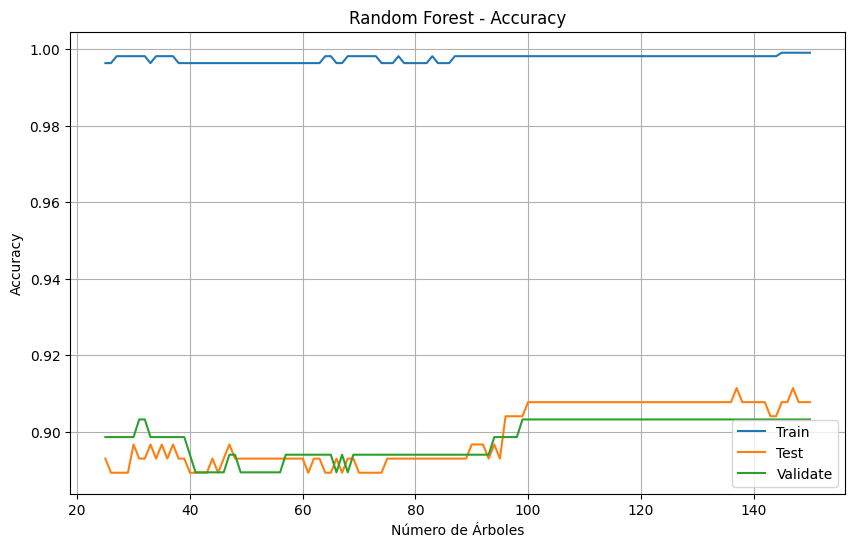

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(estimators_range, train_acc_rf, label='Train')
plt.plot(estimators_range, test_acc_rf, label='Test')
plt.plot(estimators_range, validate_acc_rf, label='Validate')

plt.xlabel('Número de Árboles')
plt.ylabel('Accuracy')
plt.title('Random Forest - Accuracy')

plt.legend()
plt.grid()

plt.show()

Esta gráfica muestra algo de overfitting, sin embargo los resultados siguen siendo decentes.

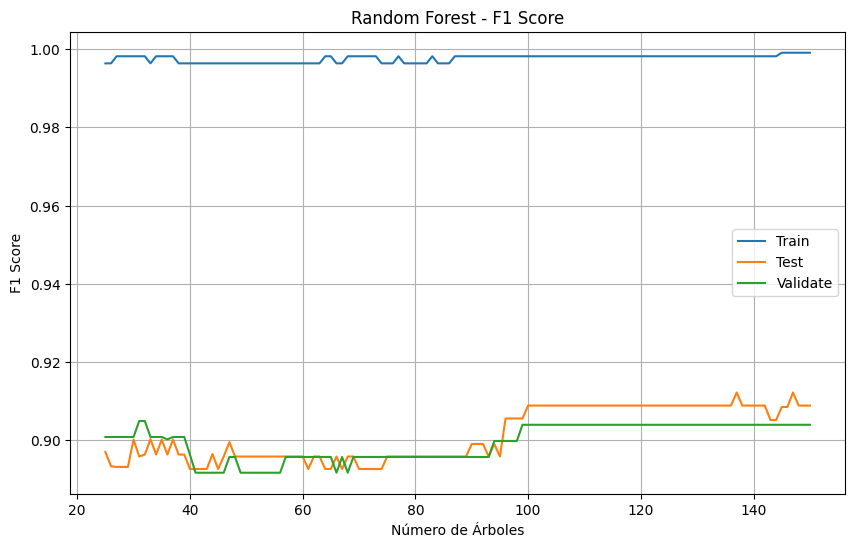

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(estimators_range, train_f1_rf, label='Train')
plt.plot(estimators_range, test_f1_rf, label='Test')
plt.plot(estimators_range, validate_f1_rf, label='Validate')

plt.xlabel('Número de Árboles')
plt.ylabel('F1 Score')
plt.title('Random Forest - F1 Score')

plt.legend()
plt.grid()

plt.show()

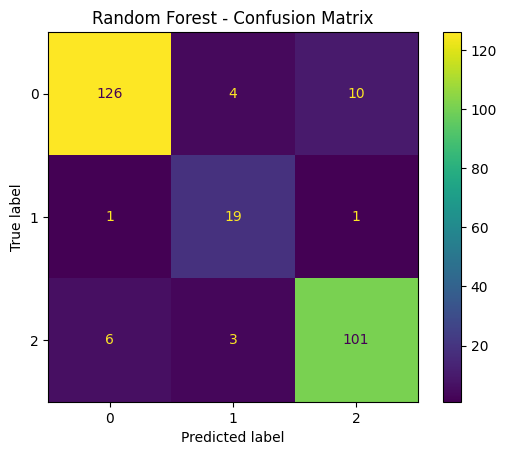

In [ ]:
y_pred_rf = rf_model.predict(X_test_encoded)

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title('Random Forest - Confusion Matrix')

plt.show()

Con este otro tipo de modelo, vemos que tiene mucho mejores resultados al identificar los sitios sospechosos.

#XGBClassifier

### Hiperparámetros:
n_estimators: Cantidad de árboles secuenciales.

learning_rate: mientras más grande sea aprende más rápido con más riesgo de overfitting

max_depth: Profundidad máxima de cada árbol. A mayor profundidad entiende patrones más complejos y aumenta overfitting

objective='multi:softmax' Le dice al xgboost que son más de dos clases

eval_metric='mlogloss': Métrica utilizada durante entrenamiento.




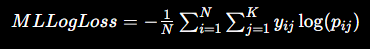

Softmax le asigna una probabilidad a cada clase.

In [ ]:
from xgboost import XGBClassifier

num_classes = len(y_train.unique())

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    n_estimators=150,
    learning_rate=0.03,
    max_depth=10,
    random_state=42,
    eval_metric='mlogloss'
)

eval_set = [
    (X_train_encoded, y_train),
    (X_test_encoded, y_test),
    (X_validate_encoded, y_validate)
]

xgb_model.fit(
    X_train_encoded,
    y_train,
    eval_set=eval_set,
    verbose=False
)

results = xgb_model.evals_result()

##Nota:
La siguiente gráfica muestra como avanza el loss en el modelo entrenado

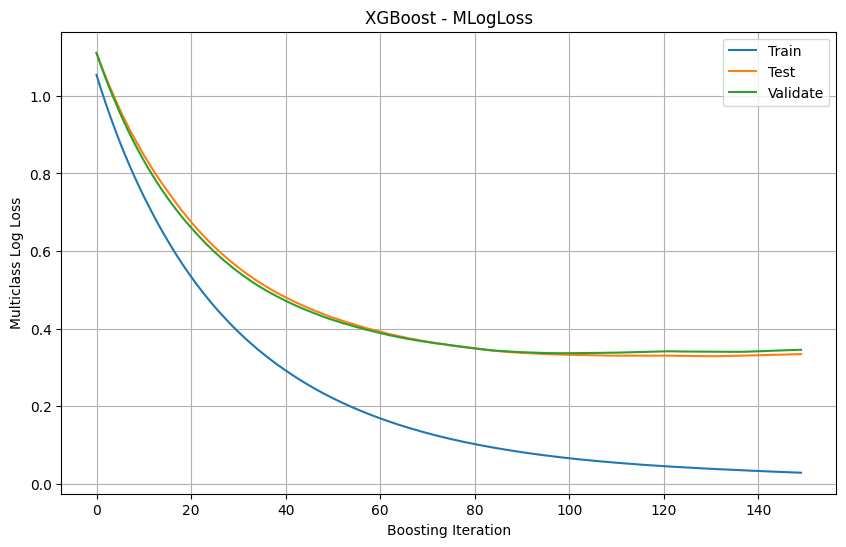

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    results['validation_0']['mlogloss'],
    label='Train'
)

plt.plot(
    results['validation_1']['mlogloss'],
    label='Test'
)

plt.plot(
    results['validation_2']['mlogloss'],
    label='Validate'
)

plt.xlabel('Boosting Iteration')
plt.ylabel('Multiclass Log Loss')
plt.title('XGBoost - MLogLoss')

plt.legend()
plt.grid()

plt.show()

In [ ]:
y_predtest_xgb = xgb_model.predict(
    X_test_encoded
)

In [ ]:
y_predval_xgb = xgb_model.predict(
    X_validate_encoded
)

In [ ]:
y_predtrain_xgb = xgb_model.predict(
    X_train_encoded
)

##Test

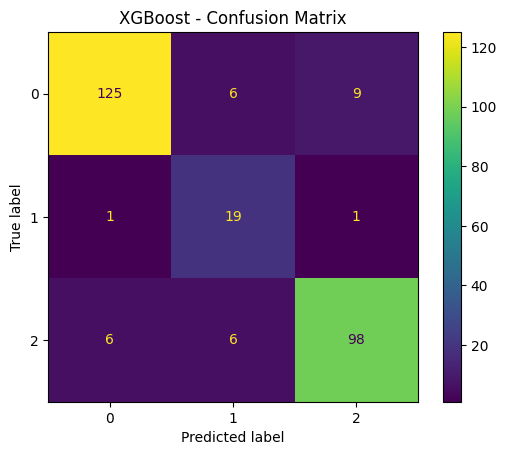

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_predtest_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

##Val

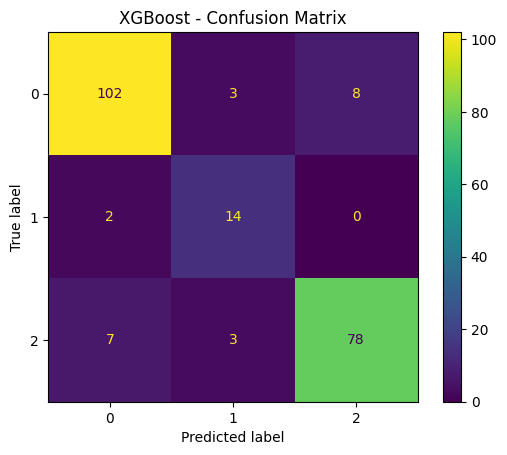

In [ ]:
cm = confusion_matrix(
    y_validate,
    y_predval_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

##Train

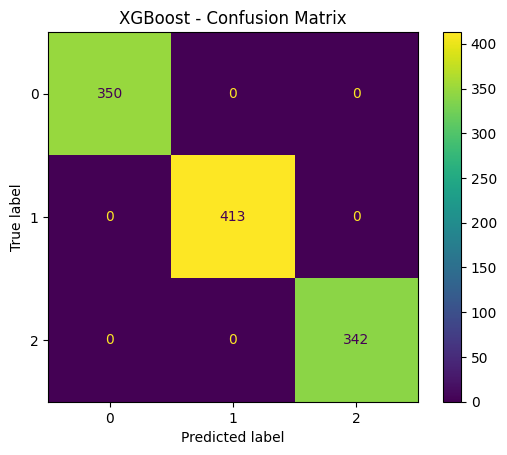

In [ ]:
cm = confusion_matrix(
    y_train,
    y_predtrain_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

##Review de XGBOOST



In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(
    classification_report(
        y_test,
        y_predtest_xgb
    )
)

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       140
           1       0.61      0.90      0.73        21
           2       0.91      0.89      0.90       110

    accuracy                           0.89       271
   macro avg       0.82      0.90      0.85       271
weighted avg       0.91      0.89      0.90       271



In [ ]:
print(
    classification_report(
        y_validate,
        y_predval_xgb
    )
)

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       113
           1       0.70      0.88      0.78        16
           2       0.91      0.89      0.90        88

    accuracy                           0.89       217
   macro avg       0.84      0.89      0.86       217
weighted avg       0.90      0.89      0.90       217



In [ ]:
print(
    classification_report(
        y_train,
        y_predtrain_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       350
           1       1.00      1.00      1.00       413
           2       1.00      1.00      1.00       342

    accuracy                           1.00      1105
   macro avg       1.00      1.00      1.00      1105
weighted avg       1.00      1.00      1.00      1105



Se puede observar algo de overfitting

#Review de todos los modelos en test

 Nota: El último modelo de random forest, no necesariamente es el mejor modelo de random forest

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_log   )
)

              precision    recall  f1-score   support

           0       0.94      0.84      0.88       140
           1       0.38      0.81      0.52        21
           2       0.90      0.83      0.86       110

    accuracy                           0.83       271
   macro avg       0.74      0.82      0.75       271
weighted avg       0.88      0.83      0.85       271



##El siguiente es el reporte de clasificación sin el encoding, como puede verse, era ligeramente peor. Sin embargo me parece interesante el probar entrenar el random forest y el xgboost sin el encoding (ya que las variables no son tan complejas [a lo mucho van de -1 a 1] y el tener más columnas podría incluso empeorar un poco el entrenamiento del modelo)

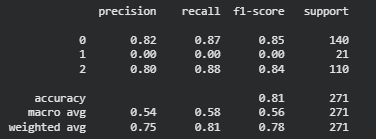

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf    )
)

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       140
           1       0.73      0.90      0.81        21
           2       0.90      0.92      0.91       110

    accuracy                           0.91       271
   macro avg       0.86      0.91      0.88       271
weighted avg       0.91      0.91      0.91       271



In [ ]:
print(
    classification_report(
        y_test,
        y_predtest_xgb
    )
)

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       140
           1       0.61      0.90      0.73        21
           2       0.91      0.89      0.90       110

    accuracy                           0.89       271
   macro avg       0.82      0.90      0.85       271
weighted avg       0.91      0.89      0.90       271



##En los tres modelos estoy obteniendo un resultado bastante decente, sin embargo se puede observar que hay algo de overfitting (en unos modelos más que en otros). Para la mejora, es buena idea mitigar el overfitting para los 3 modelos usando los hiperparámetros de cada modelo. Y aplicar la técnica de SMOTEEN para balancear mejor el set de datos

In [ ]:
import joblib

joblib.dump(log_model, "log_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")

joblib.dump(
    list(X_train_encoded.columns),
    "columnas.pkl"
)

['columnas.pkl']